In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import statsmodels.api as sm
import seaborn as sns
import bambi as bmb
import arviz as az
from sklearn.preprocessing import StandardScaler

def remove_nulls_simple(data_subset, variables):
        # Drop rows where any of the specified variable columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=variables, ignore_index=True)
        # Subsets the cleaned dataframe back into only chosen variables
        vars_cleaned = data_subset_cleaned[variables]
        return vars_cleaned

def list_to_str(list_name):
    string = " + ".join(list_name)
    return string

pa_gs = pd.read_csv('data/pa_data.csv')
temps = pd.read_csv("data/pa_temps_supplement.csv")
pa_gs = pa_gs.merge(temps, on=["station_id", "year"], how="left")

pa_gs = pa_gs[pa_gs['year'] >= 1960]
pa_gs = pa_gs.drop(['station_id', 'last_spring_frost_date', 'first_fall_frost_date', 'station_name','state'], axis=1)

def bayesian_model_standardized(data, target_var_name, cov_list):

    cov_str = list_to_str(cov_list)
    cov_list_target_var = list(cov_list) + [target_var_name] + ['year']
    data_cleaned = remove_nulls_simple(data, cov_list_target_var)
    
    sc = StandardScaler()
    data_standardized = sc.fit_transform(data_cleaned)
    data_standardized = pd.DataFrame(data_standardized)
    data_standardized.columns = data_cleaned.columns

    std = data_cleaned.std()
    
    formula = bmb.Formula(f"{target_var_name} ~ {cov_str} + year",
                      f"sigma ~ {cov_str} + year")
    model = bmb.Model(formula, data=data_standardized, dropna = True)
    output = model.fit(idata_kwargs={'log_likelihood':True})

    resid = data_cleaned[target_var_name] - model.predict(output, inplace=False).posterior["mu"].mean(("chain", "draw")).values

    return model, output, std, resid

def bayesian_model_unstandardized(data, target_var_name, cov_list):

    cov_str = list_to_str(cov_list)
    cov_list_target_var = list(cov_list) + [target_var_name] + ['year']
    data = remove_nulls_simple(data, cov_list_target_var)
    
    formula = bmb.Formula(f"{target_var_name} ~ {cov_str} + year",
                      f"sigma ~ {cov_str} + year")
    model = bmb.Model(formula, data=data, dropna = True)
    output = model.fit(idata_kwargs={'log_likelihood':True})

    resid = data[target_var_name] - model.predict(output, inplace=False).posterior["mu"].mean(("chain", "draw")).values
    
    return model, output, resid


In [14]:
def calculated_v_empirical_std(data, cov_list, target_var_name, model, output):

    cov_list_target_var = list(cov_list) + [target_var_name] + ['year']
    data_cleaned = remove_nulls_simple(data, cov_list_target_var)
    
    resids = data_cleaned['growing_season_length'].values - model.predict(output, inplace=False).posterior["mu"].mean(("chain", "draw")).values
    data_cleaned['resids'] = resids
    
    # compute predictions over chains/draws
    model.predict(output, kind="response_params") 
    # average over draws and then add to the data frame
    sigma_hats = output.posterior["sigma"].mean(("chain", "draw")).values  
    data_cleaned["sigma_hat"] = sigma_hats
    # aggregate by year
    sig_by_year = data_cleaned.groupby("year")["sigma_hat"].mean()
    # to get the empirical stds:
    empirical_stds_yearly  = data_cleaned.groupby("year")["resids"].std()
    fig, axs = plt.subplots(1,2, figsize=(8,4))
    axs[0].plot(sig_by_year, label = 'Bayesian Est. Uncertainty')
    axs[1].plot(empirical_stds_yearly, label = 'Yearly Model Residual STD')
    axs[0].legend()
    axs[1].legend()
    plt.show()

In [21]:
cov_list_1 = ['dtr_annual']
cov_list_2 = ['dtr_annual', 'tmean_spring', 'tmean_fall']
cov_list_3 = ['dtr_annual', 'tmean_spring', 'tmean_fall', 'tmax_annual']
cov_list_all = ['dtr_annual','tmean_spring','tmean_fall','latitude','longitude','tmax_annual','oni_annual',
                'nao_annual','pna_annual','amo_annual','sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station', 'dtr_spring',
                'sst_gulf_mexico','pwat_southeast_us','dewpoint_2m_southeast_us','soil_moisture_southeast_us',
                'cloud_cover_southeast_us','evaporation_southeast_us']

In [22]:
model_1, output_1, resid_1 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_list_1)
model_2, output_2, resid_2 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_list_2)
model_3, output_3, resid_3 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_list_all)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.138       31          88.73 draws/s        0:00:22    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.131       31          129.46 draws/s       0:00:15    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.137       31          156.60 draws/s       0:00:12    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.138       31          93.47 draws/s        0:00:21    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 28 seconds.


In [23]:
model_4, output_4, resid_4 = bayesian_model_unstandardized(pa_gs, 'growing_season_length', cov_list_3)

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.292       15          546.26 draws/s       0:00:03    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.319       15          382.15 draws/s       0:00:05    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.292       15          469.27 draws/s       0:00:04    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.328       15          431.69 draws/s       0:00:04    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


In [ ]:
az.summary(output_1).head(6)

In [ ]:
az.summary(output_2).head(10)

In [ ]:
az.summary(output_4).head(15)

### RESULTS FROM FULL MODEL

In [24]:
az.summary(output_3).head(50)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,124,68,10,230,3160,3381,1.00,1.2,0.85
dtr_annual,-9.5,0.46,-10,-8.8,2360,2754,1.00,0.0095,0.0066
tmean_spring,1.248,0.261,0.83,1.7,3629,3139,1.00,0.0043,0.003
tmean_fall,5.759,0.281,5.3,6.2,3718,3317,1.00,0.0046,0.0032
latitude,-2.56,0.6,-3.5,-1.6,4318,3457,1.00,0.0092,0.0067
longitude,1.403,0.206,1.1,1.7,3612,3074,1.00,0.0034,0.0024
tmax_annual,3.61,0.45,2.9,4.3,2959,3035,1.00,0.0082,0.0057
oni_annual,0.11,0.5,-0.7,0.91,4459,3087,1.00,0.0075,0.0055
nao_annual,0.32,0.85,-1,1.7,3923,3225,1.00,0.014,0.0096
pna_annual,2.23,0.87,0.8,3.6,6123,3408,1.00,0.011,0.0078


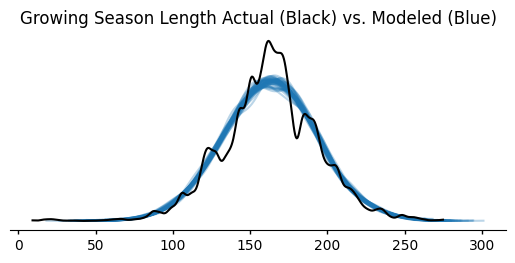

In [26]:
model_3.predict(output_3, kind="response")
az.plot_ppc_dist(output_3)
plt.title("Growing Season Length Actual (Black) vs. Modeled (Blue)")
plt.show()

In [27]:
print('SIGMA 95% Bayesian Significance Check')
posteriors_dict = {}
cov_list_all_yr = cov_list_all + ['year']
for cov in cov_list_all_yr:
    posterior = output_3.posterior[f'sigma_{cov}']
    q05, q95 = float(posterior.quantile(.05)), float(posterior.quantile(.95))
    posteriors_dict[cov] = [q05, q95, q05 <= 0 <= q95]

posteriors_df = pd.DataFrame(posteriors_dict)
post_df_names = {0:'q05', 1:'q95', 2: "crosses 0"}
posteriors_df = posteriors_df.rename(index = post_df_names)
posteriors_df[['dtr_annual','tmean_spring','tmean_fall','latitude','longitude','tmax_annual','oni_annual',
                'nao_annual','pna_annual','amo_annual','sst_north_atlantic','pwat_station','dewpoint_station',
                'soil_moisture_station','cloud_cover_station','evaporation_station']]

SIGMA 95% Bayesian Significance Check


,dtr_annual,tmean_spring,tmean_fall,latitude,longitude,tmax_annual,oni_annual,nao_annual,pna_annual,amo_annual,sst_north_atlantic,pwat_station,dewpoint_station,soil_moisture_station,cloud_cover_station,evaporation_station
q05,0.093795,0.011445,-0.004044,-0.03769,-0.033412,-0.085886,-0.007469,-0.017434,-0.000234,-0.204123,-0.154935,-0.01295,-0.07133,-0.564293,-0.582665,-0.113793
q95,0.152196,0.04718,0.03114,0.043631,-0.004543,-0.02643,0.059844,0.099286,0.123044,0.390483,0.379559,0.030622,0.008451,0.418849,0.617137,0.112036
crosses 0,False,False,True,True,False,False,True,True,True,True,True,True,True,True,True,True


In [28]:
posteriors_df[['dtr_spring','sst_gulf_mexico','pwat_southeast_us','dewpoint_2m_southeast_us',
               'soil_moisture_southeast_us','cloud_cover_southeast_us','evaporation_southeast_us', 'year']]

,dtr_spring,sst_gulf_mexico,pwat_southeast_us,dewpoint_2m_southeast_us,soil_moisture_southeast_us,cloud_cover_southeast_us,evaporation_southeast_us,year
q05,-0.086088,-0.233141,-0.05946,-0.022205,-2.455481,0.42327,-0.30598,-0.007486
q95,-0.041802,0.028249,0.012676,0.144712,0.627858,2.190239,0.016757,-0.002039
crosses 0,False,True,True,True,True,False,True,False


#### Analysis
* Changes in Variance (all significant at 95%)
    * GSL variance decreased 26.7543% from 1960 to 2025 in full model
        * Smaller models (still significant at 95%)
            * Just year and DTR - decreased by 31.41%
            * Year, DTR, Spring Temp Mean, and Fall Temp Mean - decreased by 26.42%
    * If considering temperature in full model, GSL variance increases 13.0658% for every 1 degree celsius increase in DTR (becomes less predictable) (This does not align with our expectations, work on the explanation for it)
    * GSL variance increases 2.963% for every 1 degree celsius increase in mean spring temperature

#### Analysis of DTR Variance Change across models
* Only DTR and year
    * for every degree increase in DTR, GSL decreases 4.171% (becomes more predictable)
* DTR, year >and temperature< included
    * for every degree increase in DTR, GSL increases 3.169% (becomes less predictable)
* Ran a 4th model, including Maximum Annual Temperature after noticing a jump in sigma_dtr_annual between a model not including it and a model including it (so DTR, year, temp means, and temp max included)
    * for every degree increase in DTR, GSL increases 4.739% (becomes even less predictable)
* What about temperature's inclusion in the model causes this change?
    * This flip means considering Temperature is important to DTR's impact on GSL
    * WORK ON LOGICAL EXPLANATION --> THIS IS COUNTER TO OUR HYPOTHESIS

#### Trend Analysis
* (Large model)
    * GSL is increasing at a rate of 0.21 days / year
    * for every 1 degree increase (decrease) in DTR, GSL decreases (increases) 9.51 days

In [29]:
pa_gs_60 = pa_gs[pa_gs['year'].between(1960,1961)]
pa_gs_25 = pa_gs[pa_gs['year'].between(2024,2025)]
print(f'1960 GSL Variance: {pa_gs_60['growing_season_length'].var()}')
print(f'1960 GSL Variance: {pa_gs_25['growing_season_length'].var()}')
pct_chg_gsl_var = (pa_gs_25['growing_season_length'].var() - pa_gs_60['growing_season_length'].var()) / pa_gs_60['growing_season_length'].var()
print(f'Percent Change in GSL Variability, observed: {(pct_chg_gsl_var * 100).round(2)}%')

1960 GSL Variance: 1165.1675274988042
1960 GSL Variance: 571.2638544251448
Percent Change in GSL Variability, observed: -50.97%


### DTR Trend and Variability Analysis

In [30]:
formula_dtr = bmb.Formula(f"dtr_annual ~  year",
                      f"sigma ~ year")
model_dtr = bmb.Model(formula_dtr, data=pa_gs, dropna = True)
output_dtr = model_dtr.fit(idata_kwargs={'log_likelihood':True})

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           1.167       3           2361.94 draws/s      0:00:00    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           1.009       3           2146.63 draws/s      0:00:00    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           1.149       3           1419.84 draws/s      0:00:01    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           1.238       3           2408.10 draws/s      0:00:00    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


In [31]:
az.summary(output_dtr)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,36.59,1.84,34,39,5749,3136,1.00,0.024,0.017
year,-0.01253,0.00092,-0.014,-0.011,5768,3135,1.00,1.2e-05,8.6e-06
sigma_Intercept,10.29,0.95,8.8,12,7237,3309,1.00,0.011,0.0076
sigma_year,-0.00501,0.000478,-0.0058,-0.0042,7246,3352,1.00,5.6e-06,3.8e-06


In [32]:
dtr_posterior_yr = output_dtr.posterior['year']
dtr_posterior_sigma_yr = output_dtr.posterior['sigma_year']
dtr_yr_q05, dtr_yr_q95 = float(dtr_posterior_yr.quantile(.05)), float(dtr_posterior_yr.quantile(.95))
dtr_syr_q05, dtr_syr_q95 = float(dtr_posterior_sigma_yr.quantile(.05)), float(dtr_posterior_sigma_yr.quantile(.95))
print(f'5% Year: {dtr_yr_q05}')
print(f'95% Year: {dtr_yr_q95}')
print(f'5% Sigma_Year: {dtr_syr_q05}')
print(f'95% Sigma_Year: {dtr_syr_q95}')
print("Both DTR Trend and DTR Variance Trend are significant at 95%")

5% Year: -0.014021856874021204
95% Year: -0.011020209353036062
5% Sigma_Year: -0.0057944858802801095
95% Sigma_Year: -0.004225029049223815
Both DTR Trend and DTR Variance Trend are significant at 95%


In [33]:
dtr_cov_str_all = 'tmean_spring + tmean_fall + latitude + longitude + tmax_annual + oni_annual + nao_annual + pna_annual + amo_annual + sst_north_atlantic + pwat_station + dewpoint_station + soil_moisture_station + cloud_cover_station + evaporation_station + sst_gulf_mexico + pwat_southeast_us + dewpoint_2m_southeast_us + soil_moisture_southeast_us + cloud_cover_southeast_us + evaporation_southeast_us'
formula_dtr_all = bmb.Formula(f"dtr_annual ~  {dtr_cov_str_all} + year",
                      f"sigma ~ {dtr_cov_str_all} + year")
model_dtr_all = bmb.Model(formula_dtr_all, data=pa_gs, dropna = True)
output_dtr_all = model_dtr_all.fit(idata_kwargs={'log_likelihood':True})

                                                            Grad                                                  
  Progress               Draw        Divergen…   Step size   evals       Speed                Elapsed    Remaini…  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.133       31          156.40 draws/s       0:00:12    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.192       31          157.31 draws/s       0:00:12    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.151       31          144.37 draws/s       0:00:13    0:00:00   
  ━━━━━━━━━━━━━━━━━━━━   2000        0           0.121       31          150.39 draws/s       0:00:13    0:00:00

/home/reu/.venv/lib/python3.14/site-packages/pymc/sampling/mcmc.py:1163: FutureWarning: Passing `log_likelihood` via `idata_kwargs` is deprecated and will be removed in future versions. Call `pm.compute_log_likelihood(idata)` instead.
  return _sample_return(
Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 19 seconds.


In [18]:
az.summary(output_dtr_all)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
Intercept,2.4,2.85,-2.1,7,3124,2990,1.00,0.051,0.036
tmean_spring,-0.5456,0.0104,-0.56,-0.53,4172,3338,1.00,0.00016,0.00011
tmean_fall,-0.5975,0.0103,-0.61,-0.58,5203,3746,1.00,0.00014,0.0001
latitude,0.0776,0.0275,0.034,0.12,4724,3334,1.00,0.0004,0.00028
longitude,-0.13,0.0089,-0.14,-0.12,3568,2985,1.00,0.00015,0.00011
tmax_annual,1.323,0.0133,1.3,1.3,4296,3624,1.00,0.0002,0.00015
oni_annual,0.0672,0.0229,0.031,0.1,4496,3349,1.00,0.00034,0.00024
nao_annual,-0.215,0.0373,-0.27,-0.16,4061,3394,1.00,0.00059,0.00041
pna_annual,0.038,0.0416,-0.029,0.1,4643,3334,1.00,0.00061,0.00045
amo_annual,1.869,0.131,1.7,2.1,4066,3296,1.00,0.0021,0.0015


In [19]:
dtr_2_posterior_yr = output_dtr_all.posterior['year']
dtr_2_posterior_sigma_yr = output_dtr_all.posterior['sigma_year']
dtr_2_yr_q05, dtr_2_yr_q95 = float(dtr_2_posterior_yr.quantile(.05)), float(dtr_2_posterior_yr.quantile(.95))
dtr_2_syr_q05, dtr_2_syr_q95 = float(dtr_2_posterior_sigma_yr.quantile(.05)), float(dtr_2_posterior_sigma_yr.quantile(.95))
print(f'5% Year: {dtr_2_yr_q05}')
print(f'95% Year: {dtr_2_yr_q95}')
print(f'5% Sigma_Year: {dtr_2_syr_q05}')
print(f'95% Sigma_Year: {dtr_2_syr_q95}')
print("Both DTR Trend and DTR Variance Trend are significant at 95%")

5% Year: 0.007000586193696399
95% Year: 0.012288897766236971
5% Sigma_Year: 0.0062034119714055634
95% Sigma_Year: 0.011501180723534447
Both DTR Trend and DTR Variance Trend are significant at 95%


#### Analysis
(All significant at 95%)
* Trend
    * Model of just DTR and yr
        * DTR is decreasing 0.012 degrees / year
    * Model of DTR using all covariates
        * DTR is increasing at 0.009 degrees / year
* Variance
    * Model of just DTR and yr
        * Variance in DTR has decreased 27.79% since 1960
    * Model of DTR using all covariates
        * Variance in DTR has increaed 77.76% since 1960
* Both trends show major impact of covariates on modeling of DTR --> what explains this???

In [20]:
print(pa_gs['tmean_spring'].std())

2.004610984919095
